# **I. Filtrado inicial: extracción de pacientes oncológicos del GRD**

## Objetivo
Este notebook filtra los datos de episodios hospitalarios del sistema de Grupos Relacionados por el Diagnóstico (GRD) para identificar y clasificar todos los pacientes con diagnóstico oncológico entre 2019 y 2024.

## Proceso
1. **Lectura de datos**: Carga archivos .txt del GRD público con diferentes codificaciones según el año (extraídos de datos abiertos de FONASA: https://public.tableau.com/views/PropuestaTableroGRD/PropuestaTableroGRD?%3AshowVizHome=no)
2. **Filtrado oncológico**: Identifica episodios con códigos CIE-10 de cáncer en el diagnóstico principal (DIAGNOSTICO1)
3. **Clasificación**: Agrupa los códigos de cáncer en 15 categorías según localización del tumor
4. **Salidas**:
   - Archivos CSV con datos oncológicos filtrados (en la carpeta: ``Datos oncológicos (sin procesar)``)
   - Gráficos de distribución de casos por tipo de cáncer (en la carpeta de resultados: ``Distribución de cáncer``)
   - Tablas de frecuencias para análisis (en la carpeta de resultados: ``Distribución de cáncer``)

## Clasificación de Tipos de Cáncer (CIE-10)
| Rango | Categoría |
|-------|-----------|
| C00-C14 | Labio, cavidad oral y faringe |
| C15-C26 | Órganos digestivos |
| C30-C39 | Órganos respiratorios e intratorácicos |
| C40-C41 | Hueso y cartílago articular |
| C43-C44 | Melanoma y otras neoplasias malignas de piel |
| C45-C49 | Tejidos mesoteliales y tejidos blandos |
| C50 | Mama |
| C51-C58 | Órganos genitales femeninos |
| C60-C63 | Órganos genitales masculinos |
| C64-C68 | Tracto urinario |
| C69-C72 | Ojo, cerebro y SNC |
| C73-C75 | Tiroides y otras glándulas endocrinas |
| C76-C80 | Localizaciones mal definidas y secundarias |
| C81-C96 | Tejidos linfoide, hematopoyético y relacionados |
| C97 | Múltiples localizaciones independientes |


--- Procesando Año 2019 ---
Leyendo archivo: GRD_PUBLICO_2019.txt | Codificación: latin1
Total de episodios generales: 1,151,475
Total de episodios oncológicos: 46,241 (4.02% del total)

Desglose por tipo de cáncer:
CATEGORIA_CANCER
C15-C26: Órganos digestivos                                 12611
C50: Mama                                                    6562
C81-C96: Tejidos linfoide, hematopoyético y relacionados     5252
C51-C58: Órganos genitales femeninos                         3807
C64-C68: Tracto urinario                                     3110
C76-C80: Localizaciones mal definidas y secundarias          3094
C60-C63: Órganos genitales masculinos                        2771
C30-C39: Órganos respiratorios e intratorácicos              2281
C43-C44: Melanoma y otras neoplasias malignas de piel        2255
C73-C75: Tiroides y otras glándulas endocrinas               1635
C69-C72: Ojo, cerebro y SNC                                  1317
C00-C14: Labio, cavidad oral y faringe  

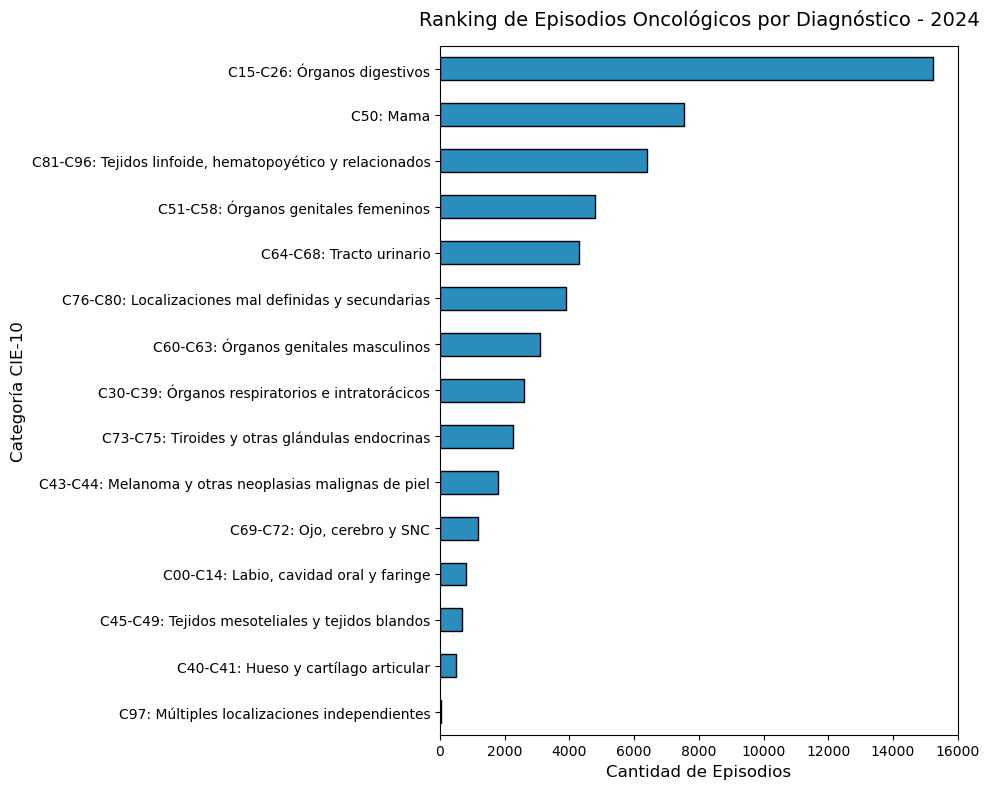

In [2]:
# Librerías a utilizar 
import pandas as pd # Importar pandas para manipulación de datos
import os # Importar os para manejo de rutas y archivos
import warnings # Importar warnings para suprimir advertencias de pandas
import matplotlib.pyplot as plt # Importar matplotlib para generación de gráficos

# Suprimir advertencias de pandas para una salida más limpia
warnings.filterwarnings('ignore') # Evita advertencias de low_memory

# ==================== CONFIGURACIÓN INICIAL ====================
# 1. Definir rutas de entrada y salida
ruta_originales = '../../Datos/Datos originales/' # Ruta donde se encuentran los archivos originales sin procesar
ruta_filtrados = '../../Datos/Datos oncológicos (sin procesar)/' # Ruta donde se guardarán los datos filtrados con episodios oncológicos
ruta_resultados = '../../Resultados/Resultados (etapa 1 y 2)/Distribución de cáncer' # Nueva ruta para guardar gráficos y distribuciones

# Crear carpetas de destino si no existen
os.makedirs(ruta_filtrados, exist_ok=True)
os.makedirs(ruta_resultados, exist_ok=True)

# ==================== CONFIGURACIÓN POR AÑO ====================
# 2. Diccionario con la configuración específica por año (archivo, columna ID, codificación)
# Nota: 2022-2023 usan UTF-16 mientras que 2019-2021 y 2024 usan Latin1
datasets = {
    "2019": ("GRD_PUBLICO_2019.txt", "CIP_ENCRIPTADO", "latin1"),
    "2020": ("GRD_PUBLICO_2020.txt", "CIP_ENCRIPTADO", "latin1"),
    "2021": ("GRD_PUBLICO_2021.txt", "CIP_ENCRIPTADO", "latin1"),
    "2022": ("GRD_PUBLICO_2022.txt", "CIP_ENCRIPTADO", "utf-16"),
    "2023": ("GRD_PUBLICO_2023.txt", "CIP_ENCRIPTADO", "utf-16"),
    "2024": ("GRD_PUBLICO_2024.txt", "ID_BENEFICIARIO", "latin1"),
}

# ==================== FUNCIONES CLASIFICADORAS ====================
# 3. Función para clasificar el tipo de cáncer según el código CIE-10 principal
def clasificar_tipo_cancer(codigo):
    '''
    - Descripción: Función que toma un código de diagnóstico (DIAGNOSTICO1) y lo clasifica en una categoría de cáncer
                   según los rangos establecidos en la clasificación CIE-10.

    - Entrada: código de diagnóstico (DIAGNOSTICO1) que se encuentra en el dataset original.
    
    - Salida: cadena con la categoría de cáncer o None si el código no es válido (o no corresponde a un diagnóstico oncológico)
    '''
    # Retorna None si el código es nulo o no válido
    if pd.isna(codigo):
        return None
    # Extraer la parte principal del código (antes del punto decimal)
    cod_base = str(codigo).split('.')[0].strip().upper()
    # Validar que comience con 'C' y tenga al menos 3 caracteres (ej: C50, C15)
    if not cod_base.startswith('C') or len(cod_base) < 3:
        return None # Si no, retorna None   
    try:
        # Extraer los dos dígitos después de 'C' para clasificación
        num = int(cod_base[1:3])
        # Clasificar según rangos CIE-10 de oncología
        if 0 <= num <= 14: return 'C00-C14: Labio, cavidad oral y faringe'
        elif 15 <= num <= 26: return 'C15-C26: Órganos digestivos'
        elif 30 <= num <= 39: return 'C30-C39: Órganos respiratorios e intratorácicos'
        elif 40 <= num <= 41: return 'C40-C41: Hueso y cartílago articular'
        elif 43 <= num <= 44: return 'C43-C44: Melanoma y otras neoplasias malignas de piel'
        elif 45 <= num <= 49: return 'C45-C49: Tejidos mesoteliales y tejidos blandos'
        elif num == 50: return 'C50: Mama'
        elif 51 <= num <= 58: return 'C51-C58: Órganos genitales femeninos'
        elif 60 <= num <= 63: return 'C60-C63: Órganos genitales masculinos'
        elif 64 <= num <= 68: return 'C64-C68: Tracto urinario'
        elif 69 <= num <= 72: return 'C69-C72: Ojo, cerebro y SNC'
        elif 73 <= num <= 75: return 'C73-C75: Tiroides y otras glándulas endocrinas'
        elif 76 <= num <= 80: return 'C76-C80: Localizaciones mal definidas y secundarias'
        elif 81 <= num <= 96: return 'C81-C96: Tejidos linfoide, hematopoyético y relacionados'
        elif num == 97: return 'C97: Múltiples localizaciones independientes'
        else: return None
    except ValueError:
        # Si no se puede convertir a entero, retorna None
        return None

# ==================== PROCESAMIENTO PRINCIPAL ====================
# 4. Procesamiento iterativo usando el diccionario de datasets
for año, (archivo_entrada, id_columna, codificacion) in datasets.items():
    # Construir ruta completa al archivo de entrada
    ruta_completa = os.path.join(ruta_originales, archivo_entrada)
    
    # Validar que el archivo exista antes de procesarlo
    if not os.path.exists(ruta_completa):
        print(f"Archivo no encontrado: {archivo_entrada}. Saltando...")
        continue
        
    # Mostrar encabezado con información del año siendo procesado
    print(f"\n{'='*50}")
    print(f"--- Procesando Año {año} ---")
    print(f"Leyendo archivo: {archivo_entrada} | Codificación: {codificacion}")
    print(f"{'='*50}")
    
    try:
        # Leer archivo CSV con separador pipe (|) y saltar filas con formato incorrecto
        df = pd.read_csv(ruta_completa, sep='|', encoding=codificacion, low_memory=False, on_bad_lines='skip')
        # Contar total de episodios generales
        total_episodios = len(df)
        # Aplicar función de clasificación a cada diagnóstico principal
        df['CATEGORIA_CANCER'] = df['DIAGNOSTICO1'].apply(clasificar_tipo_cancer)
        # Filtrar solo los registros con diagnóstico oncológico válido
        df_cancer = df[df['CATEGORIA_CANCER'].notnull()].copy()
        # Calcular estadísticas generales
        total_cancer = len(df_cancer) # Total de episodios oncológicos
        # Porcentaje de episodios oncológicos respecto al total
        porcentaje = (total_cancer / total_episodios) * 100 if total_episodios > 0 else 0
        # Mostrar resumen de los datos del año
        print(f"Total de episodios generales: {total_episodios:,}")
        print(f"Total de episodios oncológicos: {total_cancer:,} ({porcentaje:.2f}% del total)")
        # Contar episodios por tipo de cáncer
        print("\nDesglose por tipo de cáncer:") # Contar cantidad de episodios por cada categoría de cáncer
        conteo_tipos = df_cancer['CATEGORIA_CANCER'].value_counts() 
        print(conteo_tipos.to_string())
        print("-" * 40)
        
        # ==================== GUARDAR RESULTADOS ====================
        
        # Guardar tabla de frecuencias en formato CSV
        archivo_csv_resultados = os.path.join(ruta_resultados, f'distribucion_cancer_{año}.csv')
        conteo_tipos.to_csv(archivo_csv_resultados, header=['Cantidad'], index_label='Tipo_Cancer', encoding='utf-8')
        
        # Generar gráfico de barras horizontales con distribución de cánceres
        plt.clf() # Limpiar figura anterior de matplotlib para evitar sobreposición
        
        # Invertir orden para que la categoría con más casos aparezca arriba
        conteo_plot = conteo_tipos[::-1] 
        
        # Crear gráfico de barras horizontales con estilos específicos
        ax = conteo_plot.plot(kind='barh', color='#2b8cbe', edgecolor='black', figsize=(10, 8))
        
        # Configurar títulos y etiquetas
        plt.title(f'Ranking de Episodios Oncológicos por Diagnóstico - {año}', fontsize=14, pad=15)
        plt.xlabel('Cantidad de Episodios', fontsize=12)
        plt.ylabel('Categoría CIE-10', fontsize=12)
        
        # Ajustar márgenes para que los labels largos se vean completamente
        plt.tight_layout() 
        
        # Guardar gráfico con alta resolución (300 DPI)
        archivo_grafico = os.path.join(ruta_resultados, f'grafico_ranking_{año}.png')
        plt.savefig(archivo_grafico, dpi=300)
        
        # Guardar dataset filtrado con todos los episodios oncológicos
        archivo_salida = os.path.join(ruta_filtrados, f'GRD_ONCOLOGIA_{año}.csv')
        df_cancer.to_csv(archivo_salida, index=False, encoding='utf-8')
        
        # Mostrar confirmación de archivos generados
        print(f"Datos guardados exitosamente en: {archivo_salida}")
        print(f"Gráfico y distribución guardados en: {ruta_resultados}")
        
    except Exception as e:
        # Capturar y mostrar cualquier error durante el procesamiento
        print(f"Error procesando el archivo del año {año}: {e}")

# Mostrar mensaje final al terminar todo el procesamiento
print("\nProceso de extracción y generación de gráficos finalizado")